# Multimodal Eigenspectrum Decomposition

This notebook fetches neural signal datasets with natural `observations x time` structure and sustained oscillatory states. Rows are kept as stationary as practical: repeated presentations for the Neuropixels natural movie example, one posterior EEG electrode for scalp alpha, subject/channel windows for human motor ECoG, one hippocampal/rat ecephys channel or same-region channel set for rodent LFP, and selected same-state macaque ECoG windows.

Default datasets used here:

- `human_lemon_alpha`: Human scalp EEG, MPI-LEMON raw resting EEG, subject `sub-032302`, posterior eyes-closed alpha, 1 s windows at 2500 Hz. DOI: `10.15387/fcp_indi.mpi_lemon`; dataset paper DOI: `10.1038/sdata.2018.308`.
- `human_pardo_valencia_stn_beta`: Human STN LFP from Parkinson's disease patients, Pardo-Valencia et al. 2024. The default matrix uses the single strongest OFF-medication trace (`P1_1_OFF_MASTN`) and overlapping 2 s windows, preserving a narrow 17 Hz beta peak with >1000 rows. DOI: `10.1113/JP284768`; dataset DOI: `10.5281/zenodo.10078352`.
- `human_ssvep_12hz`: Human scalp EEG, MNE SSVEP example data, 12 Hz steady-state visual stimulation from one occipital channel. DOI: no dataset DOI listed in the MNE source metadata; MNE/OSF source: `https://mne.tools/stable/generated/mne.datasets.ssvep.data_path.html`.
- `mouse_neuropixels_natural_movie`: Mouse Neuropixels LFP, Allen Visual Coding natural movie, matching `notebooks/sfn2024/01_neuropixels.ipynb`. Citable source DOIs: `10.1038/s41593-019-0550-9` and `10.7554/eLife.85550`.
- `rat_medial_septum_theta`: Rat continuous ecephys, DANDI 001607 optogenetic disruption of theta-timescale spiking, single-channel sustained theta windows. DOI: no DOI listed on the DANDI draft record; source: `https://dandiarchive.org/dandiset/001607`.
- `rat_hc3_ca1_ca3`: Rat hippocampal CA1/CA3 LFP from the local CRCNS HC-3 `.eeg` file, all available hippocampal channels by default. DOI: `10.6080/K0Z60KZ9`; local file: `~/oscillatory_eigenvectors/data/hc-3/pin01-11-04/11-05_0-06-51/11-05_0-06-51.eeg`.
- `macaque_visual_grating_ecog`: Macaque ECoG, NeuroTycho visual grating task, subject K2, single selected high-kappa ECoG channel. DOI: no dataset DOI listed on the NeuroTycho visual-grating source page; source: `https://neurotycho.org/visual-grating-task`.

Optional loaders preserved in `DATASET_REGISTRY`:

- `human_eegbci_alpha`: Human scalp EEG, PhysioNet EEG Motor Movement/Imagery Dataset eyes-closed baseline, one occipital channel. DOI: `10.13026/C28G6P`.
- `human_cole_m1_beta`: Human primary motor cortex ECoG from Parkinson disease participants, Cole 2017 pre-DBS condition `B`, 23 M1 traces, beta-band benchmark for nonsinusoidal waveform-shape analysis. DOI: `10.1523/JNEUROSCI.2208-16.2017`; data/code source: `https://github.com/voytekresearch/Cole_2017`.
- `human_bciciii_ecog_motor_beta`: Human motor-cortex ECoG, BCI Competition III Dataset I. Kept as an optional loader, but no longer used as the beta example because its beta-band dominance is too weak under the hard ratio check. Source: `https://www.bbci.de/competition/iii/desc_I.html`.
- `human_miller_fingerflex_beta`: Human ECoG from the full Kai Miller FingerFlex archive. Kept as an optional loader, but no longer used in the default figure because the current row-selection/fitting check did not give a convincing beta eigenspectrum. Library DOI: `10.1038/s41562-019-0678-3`; archive source: `https://stacks.stanford.edu/file/druid:zk881ps0522/fingerflex.zip`.
- `human_sleep_spindles`: Human sleep EEG, PhysioNet Sleep-EDF Expanded, N2 windows from one EEG channel. DOI: `10.13026/C2X676`.
- `human_epilepsy_ecog`: Human intracranial ECoG/iEEG, MNE epilepsy ECoG clinical example, same-region channel windows. DOI: no dataset DOI listed in the MNE source metadata; MNE/OSF source: `https://mne.tools/stable/generated/mne.datasets.epilepsy_ecog.data_path.html`.
- `macaque_neurotycho_ecog`: Macaque NeuroTycho EEG/ECoG simultaneous recording, anesthesia/resting session, all loaded ECoG channels. DOI: no dataset DOI listed on the NeuroTycho source page; source: `https://neurotycho.org/eeg-and-ecog-simultaneous-recording`.

The default `quadrature` decomposition is exactly additive and gives the aperiodic and periodic signals the fitted AR power and positive excess power, respectively. This notebook selects `quadrature_phase`, a deterministic rule derived only from the raw eigenspectrum and fitted AR spectrum: the aperiodic signal retains the fitted spectral magnitude, the periodic residual retains raw Fourier phase wherever raw power exceeds the fit, and the two signals sum exactly to the input. The periodic PSD is the squared amplitude residual. The method uses no oscillatory balance band, pivot, signs, or dataset-specific phase correction.

The optional hierarchical decomposition is off by default. If enabled, it first splits circulant and non-circulant structure and then splits the circulant component into aperiodic fit and oscillatory residual. That option requires `method='polar'` and explicit `periodic_mode='additive'`, so each dataset needs at least as many observation rows as time samples.



In [1]:
import importlib
import os
from pathlib import Path

Path('/tmp/matplotlib').mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from eigvec.experiments import data as multimodal_data

# Reload while iterating so notebook changes pick up edits in eigvec/experiments/data.py.
multimodal_data = importlib.reload(multimodal_data)

configure_multimodal_settings = multimodal_data.configure_multimodal_settings
run_multimodal_results = multimodal_data.run_multimodal_results
plot_multimodal_decomposition_figure = multimodal_data.plot_multimodal_decomposition_figure

REFIT_RESULTS = False

In [2]:
WORKDIR = Path.cwd()
if (WORKDIR / 'notebooks').exists():
    NOTEBOOK_DIR = WORKDIR / 'notebooks'
elif WORKDIR.name == 'notebooks':
    NOTEBOOK_DIR = WORKDIR
elif WORKDIR.parent.name == 'notebooks':
    NOTEBOOK_DIR = WORKDIR.parent
else:
    NOTEBOOK_DIR = WORKDIR

DATA_ROOT = NOTEBOOK_DIR / 'data' / 'multimodal_cache'
ALLEN_CACHE = NOTEBOOK_DIR / 'data' / 'ecephys_cache_dir'
DATA_ROOT.mkdir(parents=True, exist_ok=True)

DATASET_KEYS = [
    'human_lemon_alpha',
    'human_pardo_valencia_stn_beta',
    # 'human_cole_m1_beta',
    # 'human_ssvep_12hz',
    'macaque_visual_grating_ecog',
    'rat_medial_septum_theta',
    'rat_hc3_ca1_ca3',
    'mouse_neuropixels_natural_movie',
]
DATASET_KEYS = DATASET_KEYS[::-1]

WINDOW_S = 1.0
N_PLOT = 5
MIN_KAPPA = 0.9
KAPPA_TARGET = 0.95
PSD_ORDER = 5
PERIODIC_DECOMPOSITION_MODE = "quadrature_phase"
# Used for row scoring and display only; it does not enter the decomposition.
PERIODIC_SCORE_BAND = (6, 120)
LINE_NOISE_BASES = (50, 60)
ROW_QC_PSD_DEVIANCE_Z = 3.0

APPLY_SIGNAL_QC = True
STANDARDIZE_FOR_MODEL = True
SIGNAL_QC_PSD_RANGE = (1, 120)
SIGNAL_QC_MIN_OSC_PROMINENCE = 2.0
SIGNAL_QC_MIN_OSC_FRACTION = 0.08
SIGNAL_QC_MIN_HALF_PSD_CORR = 0.35
SIGNAL_QC_MIN_PSD_REFERENCE_CORR = 0.40
SIGNAL_QC_MAX_MEAN_ROBUST_Z = 8.0
SIGNAL_QC_MAX_LOG_STD_ROBUST_Z = 6.0
SIGNAL_QC_MIN_ROWS_PER_DATASET = 250

ROW_QC_MEAN_Z = 5.0
ROW_QC_STD_LOG_Z = 5.0
ROW_QC_MAX_ITER = 8
ROW_QC_FREQ_RANGE = (1, 120)
ROW_QC_CHUNK_ROWS = 4096
LINE_NOISE_BASE_WIDTH = 6.0
LINE_NOISE_HARMONIC_WIDTH = 4.0
NEUROTYCHO_WINDOWS = 10_000

In [3]:
LEMON_EEG_S3_PREFIX = 'https://fcp-indi.s3.amazonaws.com/data/Projects/INDI/MPI-LEMON/Compressed_tar/EEG_MPILMBB_LEMON/EEG_Raw_BIDS_ID'

COLE_2017_REPO_URL = 'https://github.com/voytekresearch/Cole_2017.git'
COLE_2017_DATA_URL = 'https://github.com/voytekresearch/Cole_2017/raw/master/data.mat'

BCICIII_ECOG_TRAIN_URL = 'https://www.bbci.de/competition/download/competition_iii/tuebingen/Competition_train.mat.gz'
BCICIII_ECOG_DESC_URL = 'https://www.bbci.de/competition/iii/desc_I.html'
BCICIII_ECOG_SELECTED_CHANNELS = (52, 30, 51, 29, 44)
BCICIII_ECOG_SCORE_BAND = (16, 30)
BCICIII_ECOG_SIGNAL_QC_MIN_ROWS = 2000
BCICIII_ECOG_MIN_ANALYSIS_ROWS = 1000

PARDO_VALENCIA_RECORD_URL = 'https://zenodo.org/records/10078352'
PARDO_VALENCIA_DATASET_DOI = '10.5281/zenodo.10078352'
PARDO_VALENCIA_PAPER_DOI = '10.1113/JP284768'
PARDO_VALENCIA_DATASET_URLS = {
    1: 'https://zenodo.org/records/10078352/files/dataset_1.zip?download=1',
    2: 'https://zenodo.org/records/10078352/files/dataset_2.zip?download=1',
}
PARDO_VALENCIA_FS_BY_PATIENT = {
    **{patient: 5000.0 for patient in range(1, 17)},
    **{patient: 2000.0 for patient in range(17, 22)},
}
PARDO_VALENCIA_BETA_BAND = (13, 35)
PARDO_VALENCIA_SURROUND_BANDS = ((6, 12), (36, 55))
PARDO_VALENCIA_TARGET_FS = 1000.0
PARDO_VALENCIA_NARROW_TRACE = (1, 'P1_1_OFF_MASTN.mat')
PARDO_VALENCIA_WINDOW_SECONDS = 2.0
PARDO_VALENCIA_STEP_SECONDS = 0.075

MILLER_FINGERFLEX_URL = 'https://stacks.stanford.edu/file/druid:zk881ps0522/fingerflex.zip'
MILLER_FINGERFLEX_SUBJECT_CODES = ('bp', 'cc', 'ht', 'jc', 'jp', 'mv', 'wc', 'wm', 'zt')
MILLER_FINGER_LABELS = {1: 'thumb', 2: 'index', 3: 'middle', 4: 'ring', 5: 'little'}
MILLER_FINGERFLEX_CLEAN_BETA_CONFIGS = (
    {'subject': 'ht', 'channel': 48, 'band': (20.0, 27.0), 'description': 'HT motor grid narrow beta'},
    {'subject': 'jc', 'channel': 20, 'band': (18.0, 24.0), 'description': 'JC motor grid beta'},
    {'subject': 'jp', 'channel': 10, 'band': (17.0, 24.0), 'description': 'JP motor grid beta'},
    {'subject': 'wc', 'channel': 7, 'band': (17.0, 23.0), 'description': 'WC motor grid beta'},
    {'subject': 'zt', 'channel': 5, 'band': (18.0, 24.0), 'description': 'ZT motor grid beta'},
)
MILLER_FINGERFLEX_DROPPED_BY_DEFAULT = ('bp', 'cc', 'mv', 'wm')
MILLER_FINGERFLEX_DROPPED_REASONS = {
    'bp': 'strong local beta, but adding it to the maximum-row pooled subset dropped pooled kappa below 0.9',
    'cc': 'weaker/less stable beta under pooled row-selection check',
    'mv': 'weaker/less stable beta under pooled row-selection check',
    'wm': 'weaker/less stable beta under pooled row-selection check',
}

DATASET_REGISTRY = {
    'human_eegbci_alpha': multimodal_data.load_human_eegbci,
    'human_lemon_alpha': multimodal_data.load_human_lemon_alpha,
    'human_cole_m1_beta': multimodal_data.load_human_cole_m1_beta,
    'human_pardo_valencia_stn_beta': multimodal_data.load_human_pardo_valencia_stn_beta,
    'human_bciciii_ecog_motor_beta': multimodal_data.load_human_bciciii_ecog_motor_beta,
    'human_miller_fingerflex_beta': multimodal_data.load_human_miller_fingerflex_beta,
    'human_sleep_spindles': multimodal_data.load_human_sleep_spindles,
    'human_ssvep_12hz': multimodal_data.load_human_ssvep,
    'human_epilepsy_ecog': multimodal_data.load_human_epilepsy_ecog,
    'mouse_neuropixels_natural_movie': multimodal_data.load_mouse_neuropixels_natural_movie,
    'rat_hc3_ca1_ca3': multimodal_data.load_hc3_hippocampal_eeg,
    'rat_medial_septum_theta': multimodal_data.load_rat_medial_septum_theta,
    'macaque_visual_grating_ecog': multimodal_data.load_macaque_visual_grating_ecog,
    'macaque_neurotycho_ecog': lambda: multimodal_data.load_neurotycho_signal('ECoG'),
}

In [4]:
FIT_CHUNK_ROWS = 4096
SCORE_CHUNK_ROWS = 4096
PSD_AR_BOUNDS = (-0.95, 0.95)
PSD_FIRST_PHI_GUESS = 0.8
PSD_LOSS = 'huber'
PSD_F_SCALE = 0.15
PSD_MAXFEV = 50000
PSD_FIT_MIN_FREQ = 1.0
PSD_FIT_MAX_FREQ = None
PSD_FIT_RESID_Z = 2.5
PSD_FIT_ITERATIONS = 2
PSD_FALLBACK_ORDER = 5
N_CANDIDATE_ROWS = 1024
MAX_SCORE_ROWS = 50000

MIN_PERIODIC_PEAK_FRACTION = 0.8
MIN_SPECTRAL_PEAK_RATIO = 1.25
MAX_LINE_NOISE_FRACTION = 0.1
MIN_VARIANCE_BALANCE = 0.02
SUSTAINED_SEGMENT_S = 0.2
SUSTAINED_RMS_RATIO = 0.35
MIN_SUSTAINED_FRACTION = 0.8
KAPPA_SELECTION_QUANTILES = (1.0, 0.995, 0.99, 0.98, 0.95, 0.9, 0.85, 0.8, 0.7)
MIN_KAPPA_SELECTION_ROWS = 30
PLOT_ROW_MIN_RAW_PERIODIC_CORR = 0.9

PUBLICATION_AR_FIT_SETTINGS = {
    'use_robust_aperiodic_ar': True,
    'order': 100,
    'fallback_order': 50,
    'order_sequence': (100, 50, 25, 10),
    'fit_min_freq': 1e-9,
    'fit_max_freq': 550.0,
    'exclude_bands': (),
    'loss_fn': 'huber',
    'f_scale': 0.1,
    'maxfev': 50_000,
    'asymmetric_overfit_penalty': False,
    'overfit_weight': 0.0,
    'low_freq_residual_weight': 1.0,
    'low_freq_overfit_weight': 0.0,
    'low_freq_max': 5.0,
    'overfit_tolerance_log10': 0.1,
    'ceiling_to_data': False,
    'mask_peaks_for_fit': True,
    'peak_mask_min_freq': 5.0,
    'peak_mask_window': 5,
    'peak_mask_threshold': 0.75,
}
FAST_PUBLICATION_AR_FIT_SETTINGS = {
    **PUBLICATION_AR_FIT_SETTINGS,
    'order': 10,
    'fallback_order': 5,
    'order_sequence': (10, 5, 3),
}
DEFAULT_PSD_FIT_SETTINGS_BY_DATASET = {
    'human_pardo_valencia_stn_beta': {
        **FAST_PUBLICATION_AR_FIT_SETTINGS,
        'exclude_bands': ((13.0, 35.0),),
        'fit_max_freq': 120.0,
        'order': 5,
        'fallback_order': 3,
        'order_sequence': (5, 3),
    },
    'human_bciciii_ecog_motor_beta': {
        **FAST_PUBLICATION_AR_FIT_SETTINGS,
        'exclude_bands': ((8.0, 30.0),),
        'fit_max_freq': 120.0,
        'order': 5,
        'fallback_order': 3,
        'order_sequence': (5, 3),
    },
    'human_miller_fingerflex_beta': {
        'exclude_bands': ((12.0, 20.0),),
        'fit_max_freq': 120.0,
        'order': 5,
        'fallback_order': 3,
    },
}
SUGGESTED_PSD_FIT_SETTINGS_BY_DATASET = {
    'macaque_visual_grating_ecog': {
        **FAST_PUBLICATION_AR_FIT_SETTINGS,
        'fit_max_freq': 120.0,
    },
    'Macaque ECoG: visual grating': {
        **FAST_PUBLICATION_AR_FIT_SETTINGS,
        'fit_max_freq': 120.0,
    },
}

RESULT_CACHE_DIR = DATA_ROOT / 'result_cache'
RESULT_CACHE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_CACHE_VERSION = 'multimodal-results-v19-deterministic-phase-transfer'

CACHE_RESULTS = True
DATASET_CACHE_VERSION_BY_KEY = {
    'human_lemon_alpha': 'lemon-window-1.0',
    'human_pardo_valencia_stn_beta': 'pardo-valencia-p1-mastn-2s-step075-v1',
    'human_bciciii_ecog_motor_beta': 'bciciii-i-top5-1s-qc2000-v1',
    'human_miller_fingerflex_beta': 'full-stanford-clean-beta-pooled-v2-maxrows-kappa09',
}
PSD_CACHE_SETTING_ALIASES_BY_KEY = {
    'human_cole_m1_beta': ('Human M1 ECoG: Cole 2017 Parkinson beta',),
    'human_pardo_valencia_stn_beta': ('Human STN LFP: Pardo-Valencia Parkinson beta',),
    'human_bciciii_ecog_motor_beta': ('Human ECoG: BCI III motor mu/beta',),
    'human_miller_fingerflex_beta': tuple(
        f'Human ECoG: Miller FingerFlex beta {code}'
        for code in MILLER_FINGERFLEX_SUBJECT_CODES
    ),
    'macaque_visual_grating_ecog': ('Macaque ECoG: visual grating',),
}
RESULT_CACHE_SETTING_NAMES = [
    'WINDOW_S',
    'N_PLOT',
    'MIN_KAPPA',
    'KAPPA_TARGET',
    'PSD_ORDER',
    'PERIODIC_DECOMPOSITION_MODE',
    'PERIODIC_SCORE_BAND',
    'LINE_NOISE_BASES',
    'ROW_QC_PSD_DEVIANCE_Z',
    'ROW_QC_MEAN_Z',
    'ROW_QC_STD_LOG_Z',
    'ROW_QC_MAX_ITER',
    'ROW_QC_FREQ_RANGE',
    'APPLY_SIGNAL_QC',
    'STANDARDIZE_FOR_MODEL',
    'SIGNAL_QC_PSD_RANGE',
    'SIGNAL_QC_MIN_OSC_PROMINENCE',
    'SIGNAL_QC_MIN_OSC_FRACTION',
    'SIGNAL_QC_MIN_HALF_PSD_CORR',
    'SIGNAL_QC_MIN_PSD_REFERENCE_CORR',
    'SIGNAL_QC_MAX_MEAN_ROBUST_Z',
    'SIGNAL_QC_MAX_LOG_STD_ROBUST_Z',
    'SIGNAL_QC_MIN_ROWS_PER_DATASET',
    'FIT_CHUNK_ROWS',
    'SCORE_CHUNK_ROWS',
    'PSD_AR_BOUNDS',
    'PSD_FIRST_PHI_GUESS',
    'PSD_LOSS',
    'PSD_F_SCALE',
    'PSD_MAXFEV',
    'PSD_FIT_MIN_FREQ',
    'PSD_FIT_MAX_FREQ',
    'PSD_FIT_RESID_Z',
    'PSD_FIT_ITERATIONS',
    'PSD_FALLBACK_ORDER',
    'N_CANDIDATE_ROWS',
    'MAX_SCORE_ROWS',
    'MIN_PERIODIC_PEAK_FRACTION',
    'MIN_SPECTRAL_PEAK_RATIO',
    'MAX_LINE_NOISE_FRACTION',
    'MIN_VARIANCE_BALANCE',
    'SUSTAINED_SEGMENT_S',
    'SUSTAINED_RMS_RATIO',
    'MIN_SUSTAINED_FRACTION',
    'PLOT_ROW_MIN_RAW_PERIODIC_CORR',
    'KAPPA_SELECTION_QUANTILES',
    'MIN_KAPPA_SELECTION_ROWS',
]

In [5]:
# Mouse Neuropixels LFP: natural movie
# Rat HC-3 hippocampus: CA1/CA3 LFP
# Rat ecephys: medial septal theta
# Macaque ECoG: visual grating
# Human M1 ECoG: Cole 2017 Parkinson beta
# Human EEG: LEMON eyes-closed alpha

CUSTOM_PSD_FIT_SETTINGS_BY_DATASET = {
    "human_pardo_valencia_stn_beta": dict(
        order=50,
        order_sequence=None,
        fallback_order=None,
        fit_min_freq=1e-9,
        fit_max_freq=1000.0,
        exclude_bands=((14.0, 22.0), (40, 65)),
        loss_fn="huber",
        f_scale=0.01,
        maxfev=50_000,
        mask_peaks_for_fit=False,
        peak_mask_min_freq=5.0,
        peak_mask_window=5,
        peak_mask_threshold=0.75,
        asymmetric_overfit_penalty=True,
        overfit_weight=100.0,
        low_freq_residual_weight=1000.0,
        low_freq_overfit_weight=0.0,
        low_freq_max=10.0,
        overfit_tolerance_log10=0.1,
        ceiling_to_data=False,
    ),
    "human_bciciii_ecog_motor_beta": dict(
        order=5,
        fallback_order=3,
        order_sequence=(5, 3),
        fit_min_freq=1e-9,
        fit_max_freq=120.0,
        fill_outside_fit_range_with_raw=False,
        plot_fit_range_only=None,
        exclude_bands=((8.0, 30.0),),
        include_line_noise=False,
        use_robust_aperiodic_ar=True,
        mask_peaks_for_fit=True,
        peak_mask_min_freq=5.0,
        peak_mask_window=5,
        peak_mask_threshold=0.75,
        fit_iterations=1,
        loss_fn="huber",
        f_scale=0.1,
    ),
    "human_lemon_alpha": dict(
        order=20,
        fallback_order=None,
        fit_min_freq=0.0,
        fit_max_freq=10_000,
        exclude_bands=((5, 15),),
        include_line_noise=False,
        fit_iterations=1,
        loss_fn="linear",
    ),
    "human_cole_m1_beta": dict(
        order=10,
        fallback_order=None,
        fit_min_freq=0.0,
        fit_max_freq=195.0,
        fill_outside_fit_range_with_raw=True,
        plot_fit_range_only=None,
        exclude_bands=((8, 33),),
        include_line_noise=True,
        fit_iterations=1,
        loss_fn = "huber",
        f_scale=0.01
    ),
    "human_ssvep_12hz": dict(
        order=65,
        fallback_order=None,
        fit_min_freq=2.0,
        fit_max_freq=10_00,
        fill_outside_fit_range_with_raw=True,
        plot_fit_range_only=False,
        exclude_bands=((8, 14), (45, 55), (245, 255), (345, 355)),
        include_line_noise=True,
        fit_iterations=1,
        loss_fn='linear',
    ),
    "mouse_neuropixels_natural_movie": dict(
        order=20,
        fallback_order=None,
        fit_min_freq=0.0,
        fit_max_freq=10_00,
        exclude_bands=((4, 9), ),
        include_line_noise=True,
        fit_iterations=1,
        loss_fn='linear',
    ),
    "rat_medial_septum_theta": dict(
        order=20,
        fallback_order=None,
        fit_min_freq=1.0,
        fit_max_freq=400.0,
        fill_outside_fit_range_with_raw=True,
        include_line_noise=True,
        fit_iterations=1,
        loss_fn='huber',
        f_scale=0.01
    ),
    "rat_hc3_ca1_ca3": dict(
        order=50,
        fallback_order=None,
        fit_min_freq=1.0,
        fit_max_freq=600.0,
        fill_outside_fit_range_with_raw=True,
        plot_fit_range_only=True,
        include_line_noise=True,
        exclude_bands=((6, 12), (55, 65), (115, 125)),
        fit_iterations=1,
        loss_fn='huber',
        f_scale=0.1
    ),
    "macaque_visual_grating_ecog": dict(
        order=25,
        order_sequence=None,
        fallback_order=None,
        fit_min_freq=0,
        fit_max_freq=480.0,
        exclude_bands=[(8, 38),],#((8.0, 22.0),),
        loss_fn="huber",
        f_scale=0.1,
        maxfev=50_000,
        mask_peaks_for_fit=False,
        peak_mask_min_freq=5.0,
        peak_mask_window=5,
        peak_mask_threshold=0.75,
        asymmetric_overfit_penalty=True,
        overfit_weight=1.0,
        low_freq_residual_weight=1000.0,
        low_freq_overfit_weight=100.0,
        low_freq_max=5.0,
        overfit_tolerance_log10=0.01,
        ceiling_to_data=False,
    )
}

APPLY_CUSTOM_PSD_SETTINGS_TO_MAIN_LOOP = True
PSD_FIT_SETTINGS_BY_DATASET = (
    {**DEFAULT_PSD_FIT_SETTINGS_BY_DATASET, **CUSTOM_PSD_FIT_SETTINGS_BY_DATASET}
    if APPLY_CUSTOM_PSD_SETTINGS_TO_MAIN_LOOP
    else DEFAULT_PSD_FIT_SETTINGS_BY_DATASET
)

MULTIMODAL_SETTINGS = {
    'WORKDIR': WORKDIR,
    'NOTEBOOK_DIR': NOTEBOOK_DIR,
    'DATA_ROOT': DATA_ROOT,
    'ALLEN_CACHE': ALLEN_CACHE,
    'DATASET_KEYS': DATASET_KEYS,
    'WINDOW_S': WINDOW_S,
    'N_PLOT': N_PLOT,
    'MIN_KAPPA': MIN_KAPPA,
    'KAPPA_TARGET': KAPPA_TARGET,
    'PSD_ORDER': PSD_ORDER,
    'PERIODIC_DECOMPOSITION_MODE': PERIODIC_DECOMPOSITION_MODE,
    'PERIODIC_SCORE_BAND': PERIODIC_SCORE_BAND,
    'LINE_NOISE_BASES': LINE_NOISE_BASES,
    'ROW_QC_PSD_DEVIANCE_Z': ROW_QC_PSD_DEVIANCE_Z,
    'APPLY_SIGNAL_QC': APPLY_SIGNAL_QC,
    'STANDARDIZE_FOR_MODEL': STANDARDIZE_FOR_MODEL,
    'SIGNAL_QC_PSD_RANGE': SIGNAL_QC_PSD_RANGE,
    'SIGNAL_QC_MIN_OSC_PROMINENCE': SIGNAL_QC_MIN_OSC_PROMINENCE,
    'SIGNAL_QC_MIN_OSC_FRACTION': SIGNAL_QC_MIN_OSC_FRACTION,
    'SIGNAL_QC_MIN_HALF_PSD_CORR': SIGNAL_QC_MIN_HALF_PSD_CORR,
    'SIGNAL_QC_MIN_PSD_REFERENCE_CORR': SIGNAL_QC_MIN_PSD_REFERENCE_CORR,
    'SIGNAL_QC_MAX_MEAN_ROBUST_Z': SIGNAL_QC_MAX_MEAN_ROBUST_Z,
    'SIGNAL_QC_MAX_LOG_STD_ROBUST_Z': SIGNAL_QC_MAX_LOG_STD_ROBUST_Z,
    'SIGNAL_QC_MIN_ROWS_PER_DATASET': SIGNAL_QC_MIN_ROWS_PER_DATASET,
    'ROW_QC_MEAN_Z': ROW_QC_MEAN_Z,
    'ROW_QC_STD_LOG_Z': ROW_QC_STD_LOG_Z,
    'ROW_QC_MAX_ITER': ROW_QC_MAX_ITER,
    'ROW_QC_FREQ_RANGE': ROW_QC_FREQ_RANGE,
    'ROW_QC_CHUNK_ROWS': ROW_QC_CHUNK_ROWS,
    'LINE_NOISE_BASE_WIDTH': LINE_NOISE_BASE_WIDTH,
    'LINE_NOISE_HARMONIC_WIDTH': LINE_NOISE_HARMONIC_WIDTH,
    'NEUROTYCHO_WINDOWS': NEUROTYCHO_WINDOWS,
    'LEMON_EEG_S3_PREFIX': LEMON_EEG_S3_PREFIX,
    'COLE_2017_REPO_URL': COLE_2017_REPO_URL,
    'COLE_2017_DATA_URL': COLE_2017_DATA_URL,
    'BCICIII_ECOG_TRAIN_URL': BCICIII_ECOG_TRAIN_URL,
    'BCICIII_ECOG_DESC_URL': BCICIII_ECOG_DESC_URL,
    'BCICIII_ECOG_SELECTED_CHANNELS': BCICIII_ECOG_SELECTED_CHANNELS,
    'BCICIII_ECOG_SCORE_BAND': BCICIII_ECOG_SCORE_BAND,
    'BCICIII_ECOG_SIGNAL_QC_MIN_ROWS': BCICIII_ECOG_SIGNAL_QC_MIN_ROWS,
    'BCICIII_ECOG_MIN_ANALYSIS_ROWS': BCICIII_ECOG_MIN_ANALYSIS_ROWS,
    'PARDO_VALENCIA_RECORD_URL': PARDO_VALENCIA_RECORD_URL,
    'PARDO_VALENCIA_DATASET_DOI': PARDO_VALENCIA_DATASET_DOI,
    'PARDO_VALENCIA_PAPER_DOI': PARDO_VALENCIA_PAPER_DOI,
    'PARDO_VALENCIA_DATASET_URLS': PARDO_VALENCIA_DATASET_URLS,
    'PARDO_VALENCIA_FS_BY_PATIENT': PARDO_VALENCIA_FS_BY_PATIENT,
    'PARDO_VALENCIA_BETA_BAND': PARDO_VALENCIA_BETA_BAND,
    'PARDO_VALENCIA_SURROUND_BANDS': PARDO_VALENCIA_SURROUND_BANDS,
    'PARDO_VALENCIA_TARGET_FS': PARDO_VALENCIA_TARGET_FS,
    'PARDO_VALENCIA_NARROW_TRACE': PARDO_VALENCIA_NARROW_TRACE,
    'PARDO_VALENCIA_WINDOW_SECONDS': PARDO_VALENCIA_WINDOW_SECONDS,
    'PARDO_VALENCIA_STEP_SECONDS': PARDO_VALENCIA_STEP_SECONDS,
    'MILLER_FINGERFLEX_URL': MILLER_FINGERFLEX_URL,
    'MILLER_FINGERFLEX_SUBJECT_CODES': MILLER_FINGERFLEX_SUBJECT_CODES,
    'MILLER_FINGER_LABELS': MILLER_FINGER_LABELS,
    'MILLER_FINGERFLEX_CLEAN_BETA_CONFIGS': MILLER_FINGERFLEX_CLEAN_BETA_CONFIGS,
    'MILLER_FINGERFLEX_DROPPED_BY_DEFAULT': MILLER_FINGERFLEX_DROPPED_BY_DEFAULT,
    'MILLER_FINGERFLEX_DROPPED_REASONS': MILLER_FINGERFLEX_DROPPED_REASONS,
    'DATASET_REGISTRY': DATASET_REGISTRY,
    'FIT_CHUNK_ROWS': FIT_CHUNK_ROWS,
    'SCORE_CHUNK_ROWS': SCORE_CHUNK_ROWS,
    'PSD_AR_BOUNDS': PSD_AR_BOUNDS,
    'PSD_FIRST_PHI_GUESS': PSD_FIRST_PHI_GUESS,
    'PSD_LOSS': PSD_LOSS,
    'PSD_F_SCALE': PSD_F_SCALE,
    'PSD_MAXFEV': PSD_MAXFEV,
    'PSD_FIT_MIN_FREQ': PSD_FIT_MIN_FREQ,
    'PSD_FIT_MAX_FREQ': PSD_FIT_MAX_FREQ,
    'PSD_FIT_RESID_Z': PSD_FIT_RESID_Z,
    'PSD_FIT_ITERATIONS': PSD_FIT_ITERATIONS,
    'PSD_FALLBACK_ORDER': PSD_FALLBACK_ORDER,
    'N_CANDIDATE_ROWS': N_CANDIDATE_ROWS,
    'MAX_SCORE_ROWS': MAX_SCORE_ROWS,
    'MIN_PERIODIC_PEAK_FRACTION': MIN_PERIODIC_PEAK_FRACTION,
    'MIN_SPECTRAL_PEAK_RATIO': MIN_SPECTRAL_PEAK_RATIO,
    'MAX_LINE_NOISE_FRACTION': MAX_LINE_NOISE_FRACTION,
    'MIN_VARIANCE_BALANCE': MIN_VARIANCE_BALANCE,
    'SUSTAINED_SEGMENT_S': SUSTAINED_SEGMENT_S,
    'SUSTAINED_RMS_RATIO': SUSTAINED_RMS_RATIO,
    'MIN_SUSTAINED_FRACTION': MIN_SUSTAINED_FRACTION,
    'KAPPA_SELECTION_QUANTILES': KAPPA_SELECTION_QUANTILES,
    'MIN_KAPPA_SELECTION_ROWS': MIN_KAPPA_SELECTION_ROWS,
    'PLOT_ROW_MIN_RAW_PERIODIC_CORR': PLOT_ROW_MIN_RAW_PERIODIC_CORR,
    'PUBLICATION_AR_FIT_SETTINGS': PUBLICATION_AR_FIT_SETTINGS,
    'FAST_PUBLICATION_AR_FIT_SETTINGS': FAST_PUBLICATION_AR_FIT_SETTINGS,
    'DEFAULT_PSD_FIT_SETTINGS_BY_DATASET': DEFAULT_PSD_FIT_SETTINGS_BY_DATASET,
    'SUGGESTED_PSD_FIT_SETTINGS_BY_DATASET': SUGGESTED_PSD_FIT_SETTINGS_BY_DATASET,
    'CUSTOM_PSD_FIT_SETTINGS_BY_DATASET': CUSTOM_PSD_FIT_SETTINGS_BY_DATASET,
    'APPLY_CUSTOM_PSD_SETTINGS_TO_MAIN_LOOP': APPLY_CUSTOM_PSD_SETTINGS_TO_MAIN_LOOP,
    'PSD_FIT_SETTINGS_BY_DATASET': PSD_FIT_SETTINGS_BY_DATASET,
    'RESULT_CACHE_DIR': RESULT_CACHE_DIR,
    'RESULT_CACHE_VERSION': RESULT_CACHE_VERSION,
    'REFIT_RESULTS': REFIT_RESULTS,
    'CACHE_RESULTS': CACHE_RESULTS,
    'DATASET_CACHE_VERSION_BY_KEY': DATASET_CACHE_VERSION_BY_KEY,
    'PSD_CACHE_SETTING_ALIASES_BY_KEY': PSD_CACHE_SETTING_ALIASES_BY_KEY,
    'RESULT_CACHE_SETTING_NAMES': RESULT_CACHE_SETTING_NAMES,
}

In [6]:
configure_multimodal_settings(MULTIMODAL_SETTINGS)
dataset_loaders = multimodal_data.dataset_loaders_for_keys(DATASET_KEYS, registry=DATASET_REGISTRY)

results, metadata_table, selected_rows_table = run_multimodal_results(
    DATASET_KEYS,
    settings=MULTIMODAL_SETTINGS,
)

Using cached fit for mouse_neuropixels_natural_movie: mouse_neuropixels_natural_movie-38a8f4ef94250a5c.pkl
Mouse Neuropixels LFP: natural movie: X=(cached), fs=500.0 Hz
  kappa=0.954 (gap to target=0.000); selected source rows=[83290, 351794, 83498, 144109, 83456]; channels/electrodes=21; trials/windows=18000
  row QC kept 333930 / 378000 rows; stationary-oscillation gate kept 337832 / 364182; fit-row selection kept 333930 / 333930 rows (q=1); AR(20) fit bins 222 / 244; fit MAE=0.023 log10
  eigenspectrum excess peak=7.0 Hz (ratio=4.41); ratio peak=7.0 Hz
  periodic peaks=7.0 Hz (frac=0.82, line=0.00, balance=0.36, sustain=1.00), 7.0 Hz (frac=0.88, line=0.00, balance=0.37, sustain=1.00), 7.0 Hz (frac=0.86, line=0.00, balance=0.35, sustain=1.00), 6.0 Hz (frac=0.64, line=0.00, balance=0.28, sustain=1.00), 7.0 Hz (frac=0.88, line=0.00, balance=0.35, sustain=1.00)
Using cached fit for rat_hc3_ca1_ca3: rat_hc3_ca1_ca3-47ef1832f99b228e.pkl
Rat HC-3 hippocampus: CA1/CA3 LFP: X=(cached), fs=12

In [7]:
from eigvec.experiments.data import (
    add_zoom_inset,
    fit_plot_mask,
    panel_scale,
    plot_empirical_component_psds,
    plot_signal_rows,
)

def plot_multimodal_decomposition_figure(
    results,
    *,
    output_path='multimodal_decomposition.svg',
    idxs_inset=None,
    include_empirical_psd=False,
    periodic_psd_min_ratio=1e-3,
    empirical_psd_interval=(0.025, 0.975),
):
    """Plot eigenspectra and signal components, optionally with empirical PSDs."""
    # The fifth column uses the eigenspectrum's full-window FFT power and
    # arithmetic mean over every retained fit row, with a 95% interval
    # for that mean. It does not estimate spectra from the five display rows.
    # Periodic bins below periodic_psd_min_ratio times the periodic peak are hidden.

    plt.rcParams.update({
        'font.size': 11,
        'axes.titlesize': 13,
        'axes.labelsize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'axes.linewidth': 0.8,
        'xtick.major.width': 0.8,
        'ytick.major.width': 0.8,
        'xtick.minor.width': 0.6,
        'ytick.minor.width': 0.6,
        'svg.fonttype': 'none',
    })

    n_rows = len(results)
    if idxs_inset is None:
        idxs_inset = [min(4, result['X_pe'].shape[0] - 1) for result in results]

    n_columns = 5 if include_empirical_psd else 4
    width_ratios = [3.0, 2.6, 3.0, 3.0]
    if include_empirical_psd:
        width_ratios.append(2.6)
    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(20 if include_empirical_psd else 16, max(4.0, 3.5 * n_rows)),
        gridspec_kw={'width_ratios': width_ratios},
    )
    if n_rows == 1:
        axes = np.asarray([axes])
    fig.set_constrained_layout_pads(w_pad=0.08, h_pad=0.06, wspace=0.10, hspace=0.10)

    column_titles = ['Signal', 'Eigenspectrum', 'Aperiodic Fit', 'Periodic Fit']
    if include_empirical_psd:
        column_titles.append('Empirical PSDs (all rows)')
    for i, result in enumerate(results):
        time = np.arange(result['X_plot'].shape[1]) / result['fs']

        signal_scale = panel_scale(result['X_plot'])
        plot_signal_rows(axes[i, 0], time, result['X_plot'], color='black', scale=signal_scale)

        powers_plot = result['powers'] / result['n_fit_rows']
        powers_fit_plot = result['powers_fit'] / result['n_fit_rows']
        spec_mask = fit_plot_mask(result['freqs'], powers_plot, result['fs'], result.get('psd_settings'))
        axes[i, 1].loglog(
            result['freqs'][spec_mask],
            powers_plot[spec_mask],
            color='C0',
            lw=1.25,
            label='Eigenvalues',
        )
        fit_mask = fit_plot_mask(result['freqs'], powers_fit_plot, result['fs'], result.get('psd_settings'))
        axes[i, 1].loglog(
            result['freqs'][fit_mask],
            powers_fit_plot[fit_mask],
            color='C1',
            lw=1.35,
            linestyle='--',
            label='Aperiodic fit',
        )
        axes[i, 1].set_box_aspect(1)
        axes[i, 1].text(
            0.06,
            0.06,
            f'$\\kappa$ = {result["kappa"]:.3f}',
            transform=axes[i, 1].transAxes,
            ha='left',
            va='bottom',
            fontsize=9.5,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2.2),
        )
        print(result['name'])
        axes[i, 0].set_ylabel(result['name'])
        if i == 0:
            axes[i, 1].legend(frameon=True, facecolor='white', framealpha=1, edgecolor='0.7')

        plot_signal_rows(axes[i, 2], time, result['X_ap'], color='C1', scale=signal_scale)
        plot_signal_rows(axes[i, 3], time, result['X_pe'], color='C2', scale=signal_scale)
        plot_signal_rows(axes[i, 2], time, result['X_plot'], color='k', alpha=0.14, lw=0.7, scale=signal_scale)
        plot_signal_rows(axes[i, 3], time, result['X_plot'], color='k', alpha=0.14, lw=0.7, scale=signal_scale)
        add_zoom_inset(axes[i, 3], time, result['X_pe'], idxs_inset[i], color='C2')
        if include_empirical_psd:
            plot_empirical_component_psds(
                axes[i, 4],
                result,
                periodic_min_ratio=periodic_psd_min_ratio,
                interval=empirical_psd_interval,
            )
            if i == 0:
                axes[i, 4].legend(
                    frameon=True,
                    facecolor='white',
                    framealpha=1,
                    edgecolor='0.7',
                )

        if i == 0:
            for j, title in enumerate(column_titles):
                axes[i, j].set_title(title, pad=8)
        if i < n_rows - 1:
            for ax in axes[i, [0, 2, 3]].ravel():
                ax.tick_params(labelbottom=False)
            axes[i, 1].tick_params(labelbottom=False)
            if include_empirical_psd:
                axes[i, 4].tick_params(labelbottom=False)

    for ax in axes[-1, [0, 2, 3]].ravel():
        ax.set_xlabel('Time (s)')
    axes[-1, 1].set_xlabel('Frequency (Hz)')
    if include_empirical_psd:
        axes[-1, 4].set_xlabel('Frequency (Hz)')

    for ax in axes[:, 0].ravel():
        ax.set_ylabel('Row')
    for ax in axes[:, 1].ravel():
        ax.set_ylabel('Power')
    for ax in axes[:, [2, 3]].ravel():
        ax.set_ylabel('Row')
    if include_empirical_psd:
        for ax in axes[:, 4].ravel():
            ax.set_ylabel('Power / Fourier bin')

    for ax in axes.ravel():
        ax.tick_params(axis='both', which='major', length=3.5)
        ax.tick_params(axis='both', which='minor', length=2)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    return fig


Mouse Neuropixels LFP: natural movie
Rat HC-3 hippocampus: CA1/CA3 LFP
Rat ecephys: medial septal theta
Macaque ECoG: visual grating
Human STN LFP: Pardo-Valencia Parkinson beta
Human EEG: LEMON eyes-closed alpha


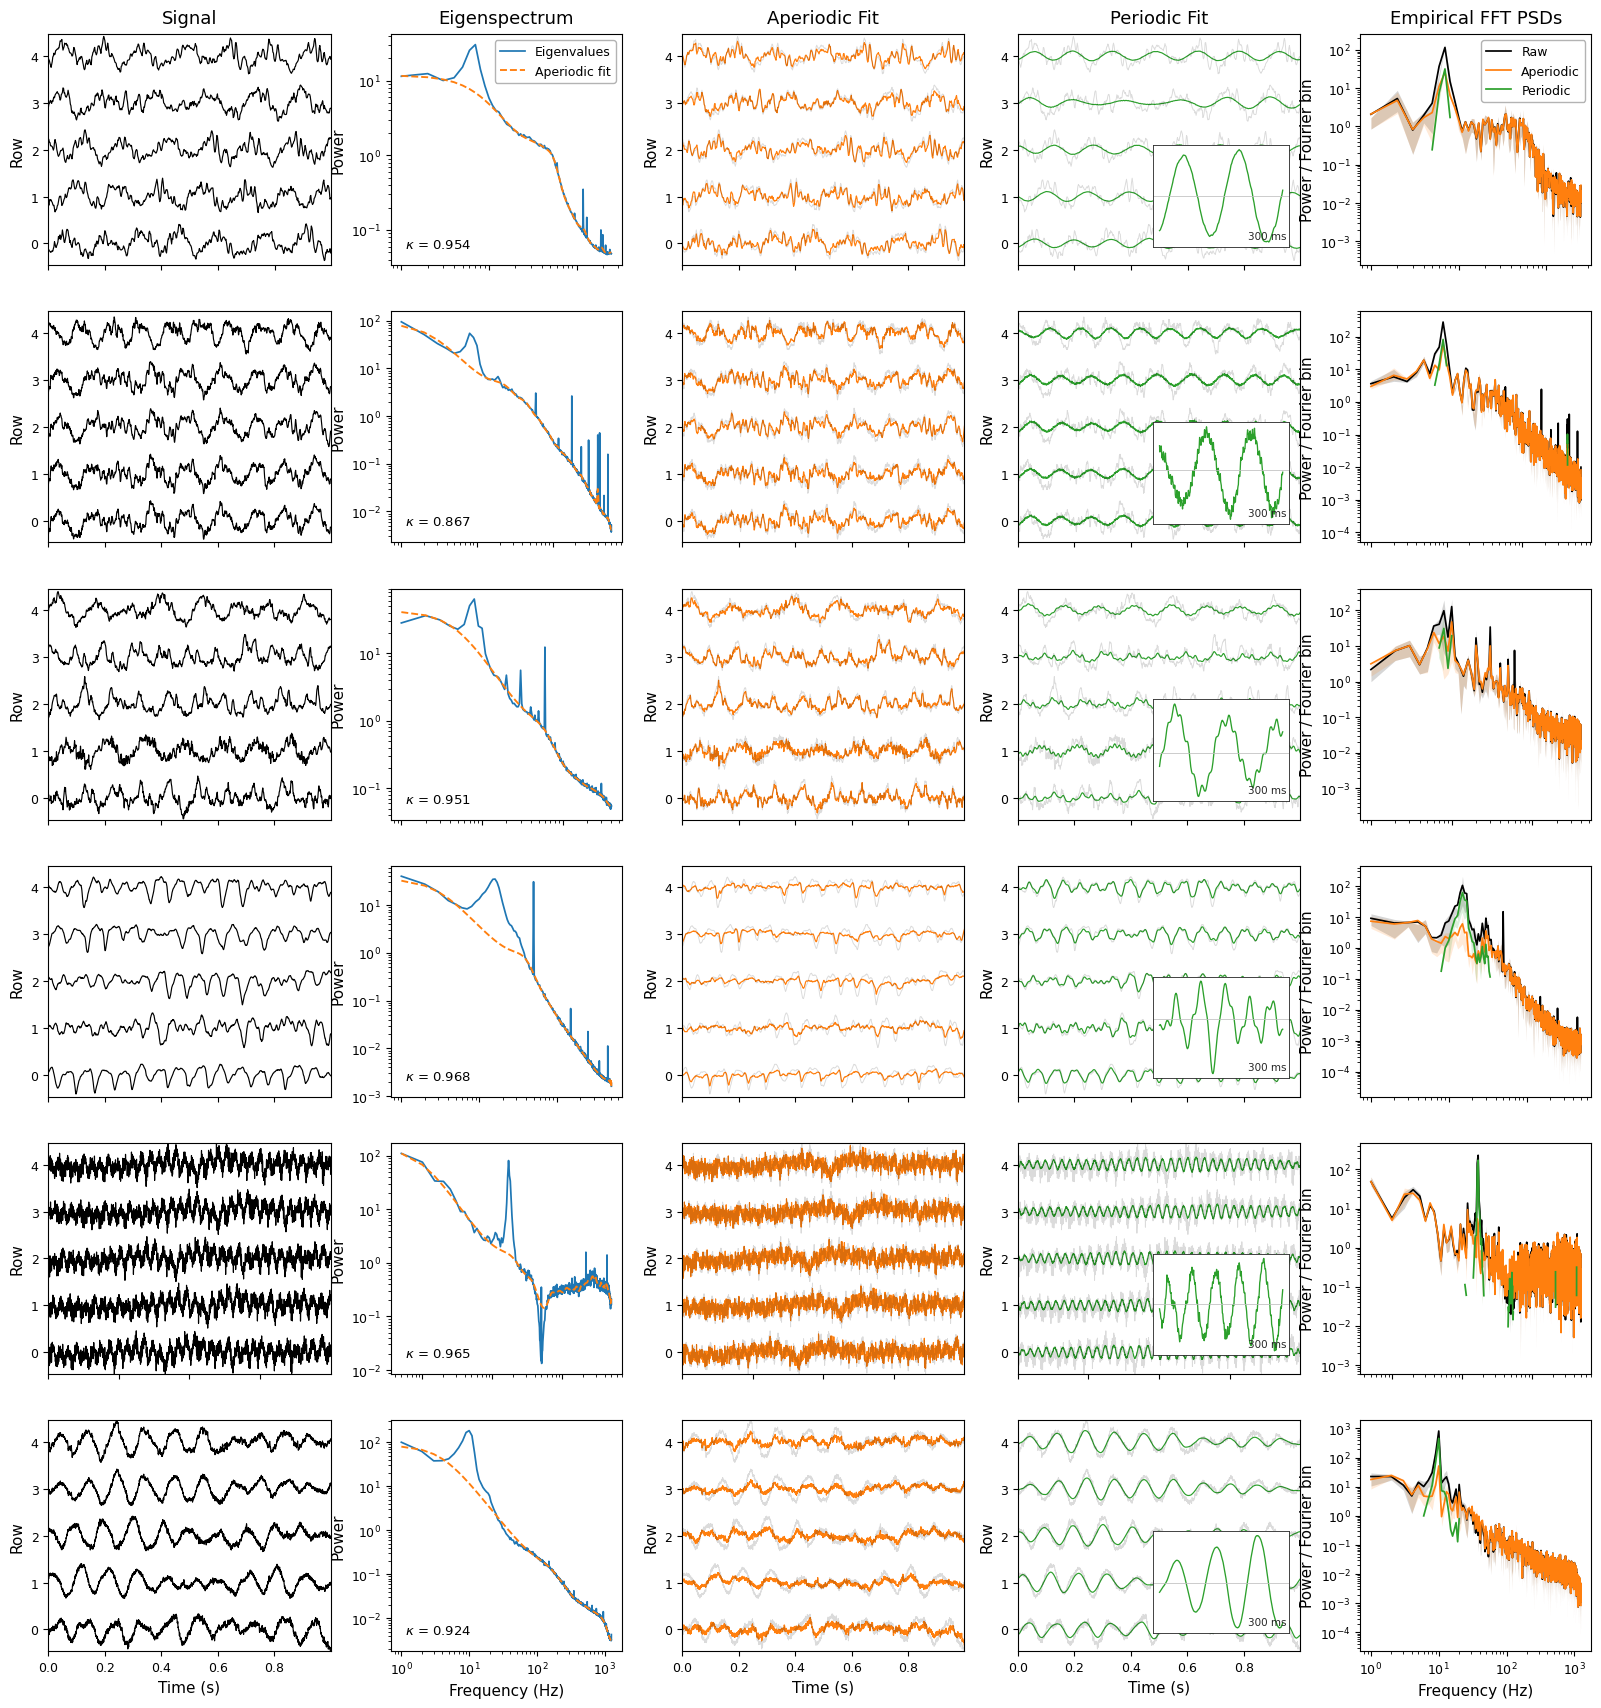

In [8]:
fig = plot_multimodal_decomposition_figure(
    results,
    output_path='multimodal_decomposition.svg',
    include_empirical_psd=True,
    periodic_psd_min_ratio=1e-3,
    empirical_psd_interval=(0.025, 0.975),
)

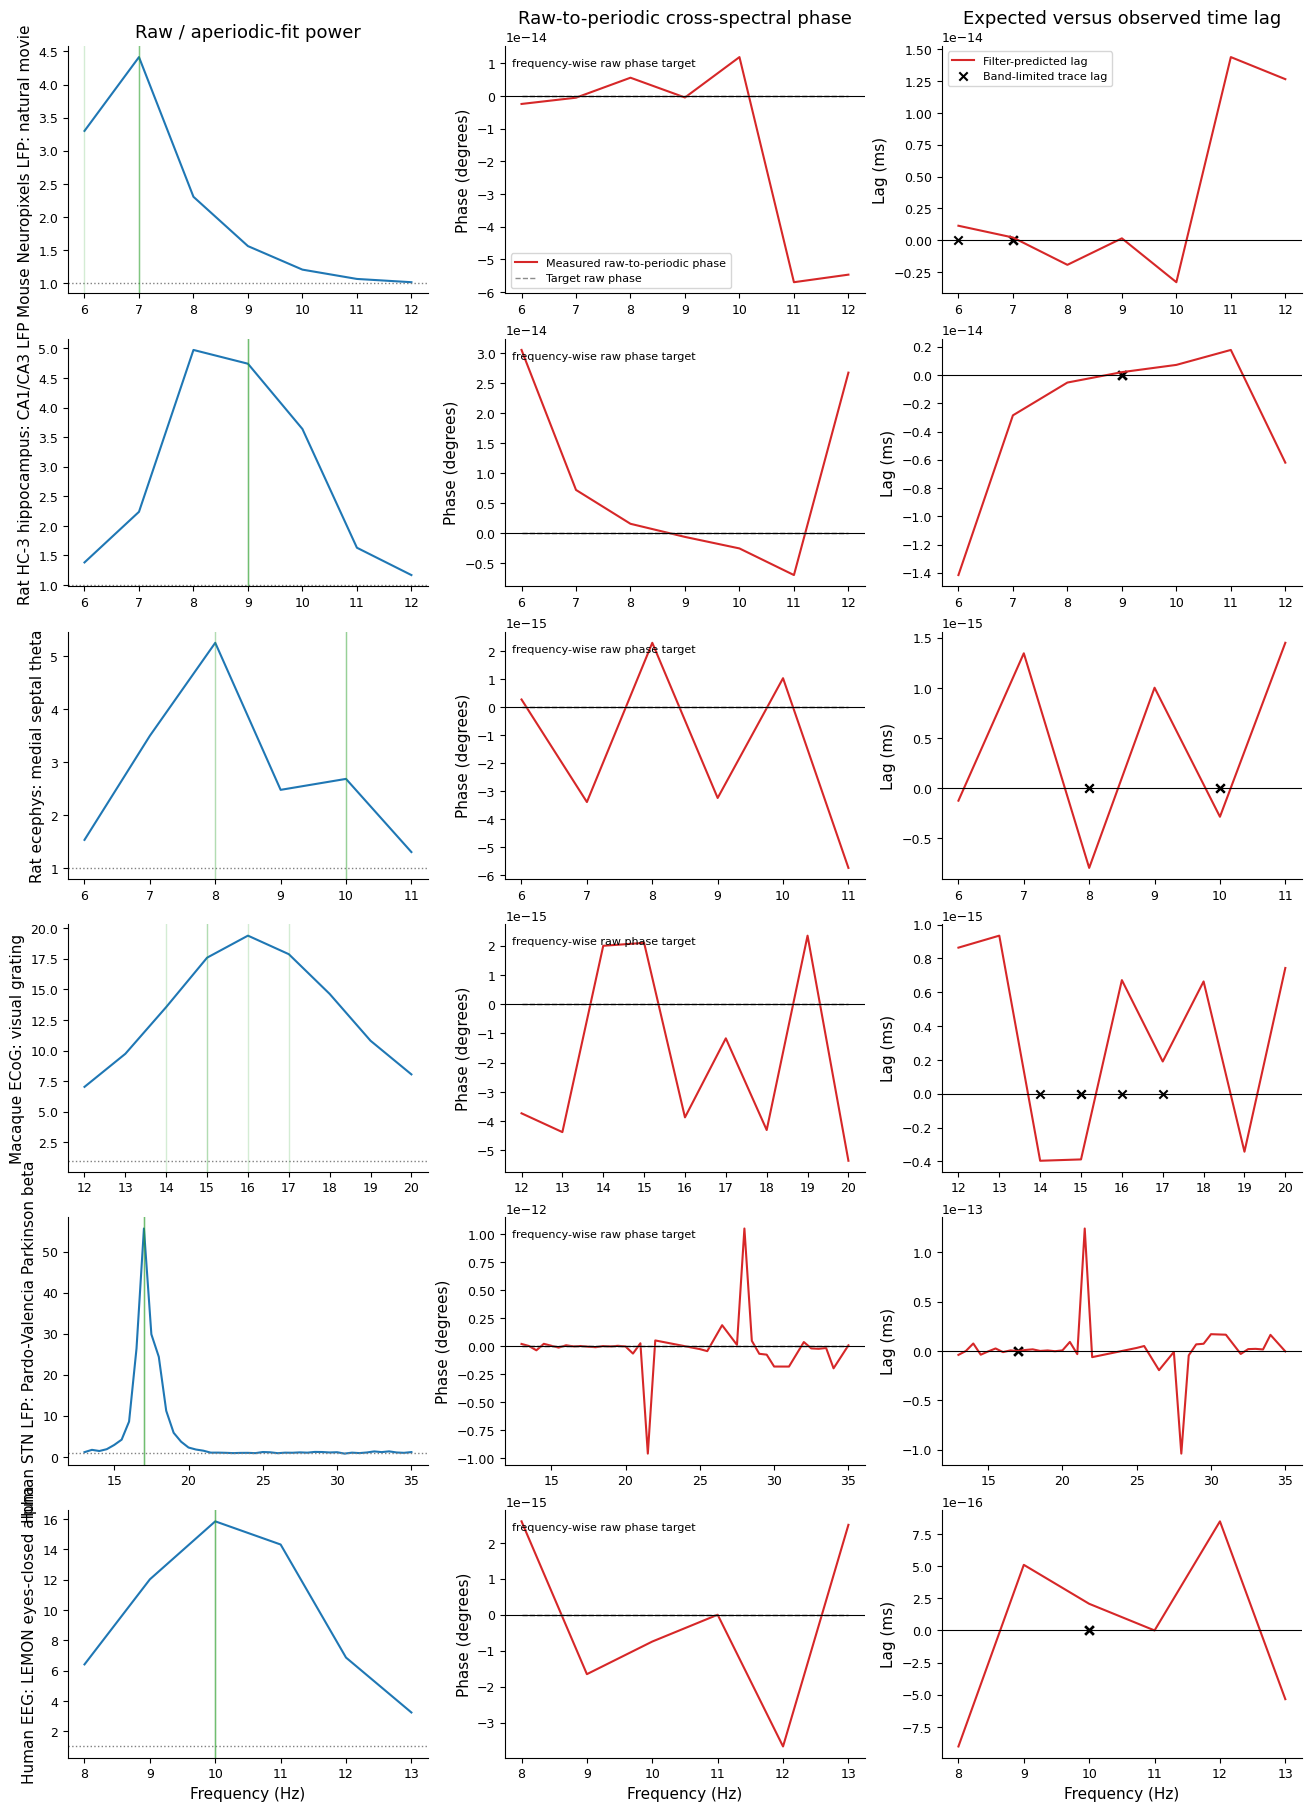

,dataset,mode,raw_periodic_phase_alignment,oscillatory_band_hz,aggregate_peak_hz,row_peak_range_hz,median_peak_phase_deg,median_predicted_lag_ms,median_xcorr_lag_ms,phase_theory_error_deg,scalar_filter_coherence,power_gain_error,relative_reconstruction_error,diagnosis
0,Mouse Neuropixels LFP: natural movie,quadrature_phase,True,"(6, 12)",7.0,"(6.0, 7.0)",-0.0,0.0,0.0,0.0,1.0,0.0,0.0,raw periodic phase aligned; expected lag is zero
1,Rat HC-3 hippocampus: CA1/CA3 LFP,quadrature_phase,True,"(6, 12)",8.0,"(9.0, 9.0)",-0.0,0.0,0.0,0.0,1.0,0.0,0.0,raw periodic phase aligned; expected lag is zero
2,Rat ecephys: medial septal theta,quadrature_phase,True,"(6, 12)",8.0,"(8.000579876013353, 10.000724845016691)",0.0,-0.0,0.0,0.0,1.0,0.0,0.0,raw periodic phase aligned; expected lag is ze...
3,Macaque ECoG: visual grating,quadrature_phase,True,"(12, 20)",16.0,"(14.0, 17.0)",0.0,0.0,0.0,0.0,1.0,0.0,0.0,raw periodic phase aligned; expected lag is ze...
4,Human STN LFP: Pardo-Valencia Parkinson beta,quadrature_phase,True,"(13, 35)",17.0,"(17.0, 17.0)",0.0,0.0,0.0,0.0,1.0,0.0,0.0,raw periodic phase aligned; expected lag is zero
5,Human EEG: LEMON eyes-closed alpha,quadrature_phase,True,"(8, 13)",10.0,"(10.0, 10.0)",0.0,0.0,0.0,0.0,1.0,0.0,0.0,raw periodic phase aligned; expected lag is zero



Interpretation:
- For quadrature_phase, phase-theory error, median peak phase, predicted lag, and band-limited cross-correlation lag should all be zero up to numerical and sample resolution.
- The method keeps the aperiodic spectral magnitude equal to the fit and keeps exact two-component signal reconstruction. Its periodic PSD is the phase-aligned amplitude residual, not orthogonal excess power.
- The same zero-phase prediction applies independently to every positive-amplitude-excess frequency, including multiple disjoint peaks.


In [9]:
# Verify the production invariants across datasets and oscillatory frequencies.
# This cell only reads results; it does not refit or modify a decomposition.
from scipy.signal import correlate, correlation_lags

PHASE_DIAGNOSTIC_MIN_EXCESS_FRACTION = 0.01


def _phase_weighted_median(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    keep = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not np.any(keep):
        return np.nan
    values, weights = values[keep], weights[keep]
    order = np.argsort(values)
    cumulative = np.cumsum(weights[order])
    return float(values[order][np.searchsorted(cumulative, cumulative[-1] / 2)])


def _bandlimited_lag_ms(z_raw, z_periodic, band_mask, fs, peak_frequency):
    n = (len(z_raw) - 1) * 2
    raw_band = np.fft.irfft(z_raw * band_mask, n=n)
    periodic_band = np.fft.irfft(z_periodic * band_mask, n=n)
    raw_band -= raw_band.mean()
    periodic_band -= periodic_band.mean()
    if np.linalg.norm(raw_band) == 0 or np.linalg.norm(periodic_band) == 0:
        return np.nan
    cross_correlation = correlate(
        periodic_band, raw_band, mode="full", method="fft"
    )
    lags = correlation_lags(n, n, mode="full")
    # Avoid selecting the neighboring oscillatory cycle.
    max_lag = max(1, int(round(fs / (2 * peak_frequency))))
    keep = np.abs(lags) <= max_lag
    lag_samples = lags[keep][np.argmax(cross_correlation[keep])]
    return float(1_000 * lag_samples / fs)


phase_dataset_records = []
phase_row_records = []
fig, phase_axes = plt.subplots(
    len(results),
    3,
    figsize=(13, max(3.0 * len(results), 4.5)),
    constrained_layout=True,
    squeeze=False,
)

for dataset_index, result in enumerate(results):
    X_raw = np.asarray(result["X_plot"], dtype=float)
    X_aperiodic = np.asarray(result["X_ap"], dtype=float)
    X_periodic = np.asarray(result["X_pe"], dtype=float)
    fs = float(result["fs"])
    n = X_raw.shape[1]
    freqs = np.asarray(result["freqs"], dtype=float)
    reference_raw_power = np.asarray(result["powers"], dtype=float)
    reference_fit_power = np.asarray(result["powers_fit"], dtype=float)
    mode = result.get("metadata", {}).get(
        "periodic_decomposition_mode", "unknown"
    )
    if len(freqs) != n // 2 + 1:
        raise ValueError(
            f"{result['key']}: expected one-sided Fourier powers"
        )

    aperiodic_fraction = np.divide(
        reference_fit_power,
        reference_raw_power,
        out=np.ones_like(reference_raw_power),
        where=reference_raw_power > 0,
    )
    aperiodic_fraction = np.clip(aperiodic_fraction, 0.0, 1.0)
    excess_fraction = 1.0 - aperiodic_fraction

    score_band = tuple(
        result.get("metadata", {}).get(
            "periodic_score_band_hz", (freqs[1], freqs[-1])
        )
    )
    band_mask = (
        (freqs >= score_band[0])
        & (freqs <= score_band[1])
        & (excess_fraction >= PHASE_DIAGNOSTIC_MIN_EXCESS_FRACTION)
        & np.isfinite(aperiodic_fraction)
    )
    if not np.any(band_mask):
        raise ValueError(
            f"{result['key']}: no excess-power bins in {score_band}"
        )

    Z_raw = np.fft.rfft(X_raw, axis=1) / np.sqrt(n)
    Z_aperiodic = np.fft.rfft(X_aperiodic, axis=1) / np.sqrt(n)
    Z_periodic = np.fft.rfft(X_periodic, axis=1) / np.sqrt(n)
    selected_raw_power = np.sum(np.abs(Z_raw) ** 2, axis=0)
    selected_aperiodic_power = np.sum(
        np.abs(Z_aperiodic) ** 2, axis=0
    )
    selected_periodic_power = np.sum(
        np.abs(Z_periodic) ** 2, axis=0
    )

    raw_periodic_cross = np.sum(
        np.conj(Z_raw) * Z_periodic, axis=0
    )
    raw_aperiodic_cross = np.sum(
        np.conj(Z_raw) * Z_aperiodic, axis=0
    )
    H_periodic = np.divide(
        raw_periodic_cross,
        selected_raw_power,
        out=np.zeros_like(raw_periodic_cross),
        where=selected_raw_power > 0,
    )
    H_aperiodic = np.divide(
        raw_aperiodic_cross,
        selected_raw_power,
        out=np.zeros_like(raw_aperiodic_cross),
        where=selected_raw_power > 0,
    )
    scalar_coherence = np.divide(
        np.abs(raw_periodic_cross) ** 2,
        selected_raw_power * selected_periodic_power,
        out=np.zeros_like(selected_raw_power),
        where=(selected_raw_power * selected_periodic_power) > 0,
    )

    measured_phase_deg = np.degrees(np.angle(H_periodic))
    expected_phase_magnitude_deg = np.zeros_like(aperiodic_fraction)
    expected_periodic_fraction = (1.0 - np.sqrt(aperiodic_fraction)) ** 2
    periodic_weights = selected_periodic_power[band_mask]
    phase_theory_error_deg = _phase_weighted_median(
        np.abs(
            np.abs(measured_phase_deg[band_mask])
            - expected_phase_magnitude_deg[band_mask]
        ),
        periodic_weights,
    )
    power_gain_error = _phase_weighted_median(
        np.abs(
            np.abs(H_periodic[band_mask]) ** 2
            - expected_periodic_fraction[band_mask]
        )
        + np.abs(
            np.abs(H_aperiodic[band_mask]) ** 2
            - aperiodic_fraction[band_mask]
        ),
        periodic_weights,
    )
    coherence_median = _phase_weighted_median(
        scalar_coherence[band_mask], periodic_weights
    )

    aggregate_peak_frequency = float(
        result.get("spectrum_quality", {}).get(
            "spectrum_excess_peak_freq",
            freqs[band_mask][np.argmax(excess_fraction[band_mask])],
        )
    )
    dataset_row_records = []
    for row_index, (z_raw, z_periodic) in enumerate(
        zip(Z_raw, Z_periodic)
    ):
        row_peak_index = np.flatnonzero(band_mask)[
            np.argmax(np.abs(z_periodic[band_mask]) ** 2)
        ]
        row_peak_frequency = float(freqs[row_peak_index])
        row_peak_phase_deg = float(
            np.degrees(
                np.angle(
                    np.conj(z_raw[row_peak_index])
                    * z_periodic[row_peak_index]
                )
            )
        )
        predicted_lag_ms = float(
            -np.radians(row_peak_phase_deg)
            / (2 * np.pi * row_peak_frequency)
            * 1_000
        )
        cross_correlation_lag_ms = _bandlimited_lag_ms(
            z_raw,
            z_periodic,
            band_mask,
            fs,
            row_peak_frequency,
        )
        record = {
            "dataset": result["name"],
            "dataset_key": result["key"],
            "row": row_index,
            "peak_frequency_hz": row_peak_frequency,
            "peak_phase_deg": row_peak_phase_deg,
            "predicted_lag_ms": predicted_lag_ms,
            "bandlimited_xcorr_lag_ms": cross_correlation_lag_ms,
        }
        dataset_row_records.append(record)
        phase_row_records.append(record)

    row_peak_frequencies = np.array(
        [record["peak_frequency_hz"] for record in dataset_row_records]
    )
    row_peak_phases = np.array(
        [record["peak_phase_deg"] for record in dataset_row_records]
    )
    predicted_lags = np.array(
        [record["predicted_lag_ms"] for record in dataset_row_records]
    )
    xcorr_lags = np.array(
        [
            record["bandlimited_xcorr_lag_ms"]
            for record in dataset_row_records
        ]
    )
    reconstruction_error = float(
        np.max(np.abs(X_raw - X_aperiodic - X_periodic))
        / max(np.max(np.abs(X_raw)), 1e-12)
    )

    if phase_theory_error_deg < 0.5 and coherence_median > 0.999:
        diagnosis = "raw periodic phase aligned; expected lag is zero"
    else:
        diagnosis = "filter/cache mismatch: inspect before interpreting phase"
    if np.ptp(row_peak_frequencies) > np.median(np.diff(freqs)):
        diagnosis += "; row peak frequency also varies"

    phase_dataset_records.append(
        {
            "dataset": result["name"],
            "mode": mode,
            "raw_periodic_phase_alignment": True,
            "oscillatory_band_hz": score_band,
            "aggregate_peak_hz": aggregate_peak_frequency,
            "row_peak_range_hz": (
                float(row_peak_frequencies.min()),
                float(row_peak_frequencies.max()),
            ),
            "median_peak_phase_deg": float(
                np.median(row_peak_phases)
            ),
            "median_predicted_lag_ms": float(
                np.median(predicted_lags)
            ),
            "median_xcorr_lag_ms": float(
                np.nanmedian(xcorr_lags)
            ),
            "phase_theory_error_deg": (
                phase_theory_error_deg
            ),
            "scalar_filter_coherence": coherence_median,
            "power_gain_error": power_gain_error,
            "relative_reconstruction_error": reconstruction_error,
            "diagnosis": diagnosis,
        }
    )

    ratio = np.divide(
        reference_raw_power,
        reference_fit_power,
        out=np.full_like(reference_raw_power, np.nan),
        where=reference_fit_power > 0,
    )
    plot_mask = (
        (freqs >= score_band[0]) & (freqs <= score_band[1])
    )
    phase_axes[dataset_index, 0].plot(
        freqs[plot_mask], ratio[plot_mask], color="C0"
    )
    phase_axes[dataset_index, 0].axhline(
        1.0, color="0.5", ls=":", lw=1
    )
    for row_peak_frequency in row_peak_frequencies:
        phase_axes[dataset_index, 0].axvline(
            row_peak_frequency, color="C2", alpha=0.2, lw=1
        )
    phase_axes[dataset_index, 0].set_ylabel(result["name"])

    phase_axes[dataset_index, 1].plot(
        freqs[band_mask],
        measured_phase_deg[band_mask],
        color="C3",
        label="Measured raw-to-periodic phase",
    )
    phase_axes[dataset_index, 1].plot(
        freqs[band_mask],
        expected_phase_magnitude_deg[band_mask],
        color="0.55",
        ls="--",
        lw=1,
        label="Target raw phase",
    )
    phase_axes[dataset_index, 1].plot(
        freqs[band_mask],
        -expected_phase_magnitude_deg[band_mask],
        color="0.55",
        ls="--",
        lw=1,
    )
    phase_axes[dataset_index, 1].axhline(
        0.0, color="k", lw=0.8
    )
    phase_axes[dataset_index, 1].text(
        0.02,
        0.95,
        "frequency-wise raw phase target",
        transform=phase_axes[dataset_index, 1].transAxes,
        ha="left",
        va="top",
        fontsize=8,
    )

    predicted_delay_curve = np.divide(
        -np.radians(measured_phase_deg),
        2 * np.pi * freqs,
        out=np.full_like(freqs, np.nan),
        where=freqs > 0,
    ) * 1_000
    phase_axes[dataset_index, 2].plot(
        freqs[band_mask],
        predicted_delay_curve[band_mask],
        color="C3",
        label="Filter-predicted lag",
    )
    phase_axes[dataset_index, 2].scatter(
        row_peak_frequencies,
        xcorr_lags,
        color="k",
        marker="x",
        label="Band-limited trace lag",
    )
    phase_axes[dataset_index, 2].axhline(
        0.0, color="k", lw=0.8
    )

for column, title in enumerate(
    (
        "Raw / aperiodic-fit power",
        "Raw-to-periodic cross-spectral phase",
        "Expected versus observed time lag",
    )
):
    phase_axes[0, column].set_title(title)
for ax in phase_axes[-1]:
    ax.set_xlabel("Frequency (Hz)")
for ax in phase_axes[:, 1]:
    ax.set_ylabel("Phase (degrees)")
for ax in phase_axes[:, 2]:
    ax.set_ylabel("Lag (ms)")
phase_axes[0, 1].legend(fontsize=8)
phase_axes[0, 2].legend(fontsize=8)
for ax in phase_axes.ravel():
    ax.spines[["top", "right"]].set_visible(False)
plt.show()

phase_dataset_diagnostics = pd.DataFrame(
    phase_dataset_records
)
phase_row_diagnostics = pd.DataFrame(phase_row_records)
display(
    phase_dataset_diagnostics.round(
        {
            "aggregate_peak_hz": 2,
            "median_peak_phase_deg": 2,
            "median_predicted_lag_ms": 2,
            "median_xcorr_lag_ms": 2,
            "phase_theory_error_deg": 3,
            "scalar_filter_coherence": 5,
            "power_gain_error": 8,
            "relative_reconstruction_error": 10,
        }
    )
)
print(
    "\nInterpretation:\n"
    "- For quadrature_phase, phase-theory error, median "
    "peak phase, predicted lag, and band-limited cross-correlation lag "
    "should all be zero up to numerical and sample resolution.\n"
    "- The method keeps the aperiodic spectral magnitude equal to the "
    "fit and keeps exact two-component signal reconstruction. Its periodic "
    "PSD is the phase-aligned amplitude residual, not orthogonal excess power.\n"
    "- The same zero-phase prediction applies independently to every "
    "positive-amplitude-excess frequency, including multiple disjoint peaks."
)